# Loan Approval Dataset: Data Understanding and Preprocessing

This notebook performs a complete data understanding and preprocessing workflow for coursework submission.

Steps included:
1. Load data from CSV
2. Inspect shape, columns, and sample rows
3. Explore summary statistics, missing values, and data types
4. Drop unnecessary ID-like columns
5. Impute missing values (mean for numeric, mode for categorical)
6. Encode categorical variables
7. Build classification and regression datasets
8. Show target value counts and plot target distribution

## 1. Import Required Libraries
Import the libraries needed for data handling, preprocessing, and visualization.

In [1]:
# Import pandas for data manipulation.
import pandas as pd
# Import numpy for numerical operations.
import numpy as np
# Import matplotlib for plotting charts.
import matplotlib.pyplot as plt
# Import seaborn to make statistical plots cleaner.
import seaborn as sns
# Import LabelEncoder to encode a categorical target when needed.
from sklearn.preprocessing import LabelEncoder
# Set a visual style for better chart readability.
sns.set_style("whitegrid")

## 2. Load Dataset and Inspect Basic Structure
Load the CSV file, then display dataset shape, column names, and the first rows.

In [2]:
# Store the dataset path in a variable for easy reuse.
csv_path = "loan_approval_data.csv"
# Read the CSV file into a pandas DataFrame.
df = pd.read_csv(csv_path)
# Print the number of rows and columns in the dataset.
print("Dataset shape:", df.shape)
# Print all column names in the dataset.
print("\nColumn names:")
# Print each column name as a list.
print(df.columns.tolist())
# Print the first five rows to preview the data.
print("\nFirst 5 rows:")
# Display the first five records from the DataFrame.
display(df.head())

Dataset shape: (58645, 13)

Column names:
['id', 'age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']

First 5 rows:


,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


## 3. Perform Data Exploration
Generate descriptive statistics, check missing values, and inspect data types.

In [3]:
# Print summary statistics for all columns where possible.
print("Summary statistics (describe):")
# Display summary statistics including both numeric and categorical columns.
display(df.describe(include="all"))
# Print the count of missing values per column.
print("\nMissing values count by column:")
# Display missing value counts in descending order.
display(df.isnull().sum().sort_values(ascending=False))
# Print the data type of each column.
print("\nData types of each column:")
# Display data types for each feature.
display(df.dtypes)

Summary statistics (describe):


,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645,58645.000000,58645,58645.000000,58634.000000,58645.000000,58640,58645.000000,58645.000000,5.864500e+04
unique,NaN,NaN,NaN,4,NaN,6,NaN,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,N,NaN,NaN,NaN
freq,NaN,NaN,NaN,30594,NaN,12271,NaN,NaN,NaN,49940,NaN,NaN,NaN
mean,29322.000000,27.550913,6.404617e+04,NaN,4.703487,NaN,9217.556518,10.677526,0.159238,NaN,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,NaN,4.004982,NaN,5563.807384,3.036034,0.091692,NaN,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,NaN,0.000000,NaN,500.000000,-11.140000,0.000000,NaN,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,NaN,2.000000,NaN,5000.000000,7.880000,0.090000,NaN,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,NaN,4.000000,NaN,8000.000000,10.750000,0.140000,NaN,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,NaN,7.000000,NaN,12000.000000,12.990000,0.210000,NaN,8.000000,0.000000,9.271600e+04



Missing values count by column:


loan_interest_rate         11
age                         6
payment_default_on_file     5
id                          0
income                      0
emplyment_length            0
home_ownership              0
loan_amount                 0
loan_intent                 0
loan_income_ratio           0
credit_history_length       0
loan_approval_status        0
max_allowed_loan            0
dtype: int64


Data types of each column:


id                           int64
age                        float64
income                       int64
home_ownership                 str
emplyment_length             int64
loan_intent                    str
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file        str
credit_history_length        int64
loan_approval_status         int64
max_allowed_loan             int64
dtype: object

## 4. Drop Unnecessary Columns (Such as ID)
Automatically detect ID-like columns and remove them from the working dataset.

In [4]:
# Create a helper function to normalize column names for matching.
def normalize_name(text):
    # Convert text to lowercase and remove spaces and underscores for robust matching.
    return str(text).strip().lower().replace(" ", "").replace("_", "")
# Build a list of columns that look like ID columns.
id_like_columns = []
# Iterate through all columns to detect ID-like patterns.
for col in df.columns:
    # Create a normalized version of the current column name.
    normalized_col = normalize_name(col)
    # Check whether the column appears to be an identifier.
    if normalized_col == "id" or normalized_col.endswith("id") or normalized_col in {"loanid", "applicationid"}:
        # Add the matched column to the drop list.
        id_like_columns.append(col)
# Print detected ID-like columns before dropping them.
print("Detected ID-like columns:", id_like_columns)
# Drop ID-like columns only if at least one such column exists.
if len(id_like_columns) > 0:
    # Remove the detected ID-like columns from the DataFrame.
    df = df.drop(columns=id_like_columns)
# Print the updated list of columns after dropping ID-like fields.
print("Remaining columns after drop:")
# Display the current column names.
print(df.columns.tolist())

Detected ID-like columns: ['id']
Remaining columns after drop:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']


## 5. Handle Missing Values
Fill missing numeric values with mean and categorical values with mode.

In [5]:
# Create a list of numeric columns in the dataset.
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# Create a list of categorical columns in the dataset.
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()
# Fill missing values in each numeric column using the column mean.
for col in numeric_columns:
    # Compute the mean value of the current numeric column.
    mean_value = df[col].mean()
    # Replace missing values in the current numeric column with the mean.
    df[col] = df[col].fillna(mean_value)
# Fill missing values in each categorical column using the column mode.
for col in categorical_columns:
    # Compute the most frequent value in the current categorical column.
    mode_value = df[col].mode(dropna=True)[0]
    # Replace missing values in the current categorical column with the mode.
    df[col] = df[col].fillna(mode_value)
# Print missing value counts after imputation to confirm completeness.
print("Missing values after imputation:")
# Display the missing value count for each column after filling.
display(df.isnull().sum())

Missing values after imputation:


age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64

## 6. Identify Target Columns and Prepare for Modeling
Find the classification target (Loan Approval Status) and regression target (Maximum Loan Amount) safely across possible naming variations.

In [6]:
# Define a helper function to locate a column from a list of candidate names.
def find_column_name(column_list, candidate_names):
    # Create a dictionary mapping normalized names to original names.
    normalized_to_original = {}
    # Loop through all existing columns to build the mapping.
    for col in column_list:
        # Build a normalized key for the current column name.
        normalized_key = str(col).strip().lower().replace(" ", "").replace("_", "")
        # Store the original column name using the normalized key.
        normalized_to_original[normalized_key] = col
    # Loop through candidate names to find the first match.
    for candidate in candidate_names:
        # Normalize the current candidate name.
        normalized_candidate = str(candidate).strip().lower().replace(" ", "").replace("_", "")
        # Return the matching original column name if it exists.
        if normalized_candidate in normalized_to_original:
            # Return the matched original column name.
            return normalized_to_original[normalized_candidate]
    # Return None when no candidate matches any column.
    return None
# Define candidate names for the classification target column.
class_target_candidates = ["loan_approval_status", "Loan Approval Status", "loan_status", "approved"]
# Define candidate names for the regression target column.
reg_target_candidates = ["max_allowed_loan", "Maximum Loan Amount", "maximum_loan_amount", "loan_amount_max"]
# Find the classification target column from the dataset.
class_target_col = find_column_name(df.columns, class_target_candidates)
# Find the regression target column from the dataset.
reg_target_col = find_column_name(df.columns, reg_target_candidates)
# Stop execution if the classification target is not found.
if class_target_col is None:
    # Raise a clear error to indicate missing classification target.
    raise ValueError("Could not find the classification target column (Loan Approval Status).")
# Stop execution if the regression target is not found.
if reg_target_col is None:
    # Raise a clear error to indicate missing regression target.
    raise ValueError("Could not find the regression target column (Maximum Loan Amount).")
# Print the selected classification and regression targets.
print("Classification target column:", class_target_col)
# Print the selected regression target column.
print("Regression target column:", reg_target_col)

Classification target column: loan_approval_status
Regression target column: max_allowed_loan


## 7. Build Classification Dataset
Create `X_class` and `y_class`, encode categorical features using one-hot encoding, and encode target labels when needed.

In [7]:
# Create a feature matrix for classification by dropping the class target column.
X_class = df.drop(columns=[class_target_col]).copy()
# Create a target vector for classification from the class target column.
y_class = df[class_target_col].copy()
# One-hot encode categorical feature columns in the classification feature matrix.
X_class = pd.get_dummies(X_class, drop_first=False)
# Check whether the target is non-numeric and requires encoding.
if not pd.api.types.is_numeric_dtype(y_class):
    # Create a LabelEncoder instance for the classification target.
    label_encoder = LabelEncoder()
    # Convert the categorical class labels into numeric labels.
    y_class = pd.Series(label_encoder.fit_transform(y_class), name=class_target_col)
# Print the shape of classification features and target.
print("X_class shape:", X_class.shape)
# Print the shape of classification target.
print("y_class shape:", y_class.shape)
# Display class distribution counts for the target variable.
print("\nValue counts of Loan Approval Status:")
# Print the class counts in descending order.
print(y_class.value_counts(dropna=False))

X_class shape: (58645, 20)
y_class shape: (58645,)

Value counts of Loan Approval Status:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64


## 8. Plot Distribution of Loan Approval Status
Visualize the target distribution with a bar chart.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29916\1055419969.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, palette="Blues_d")


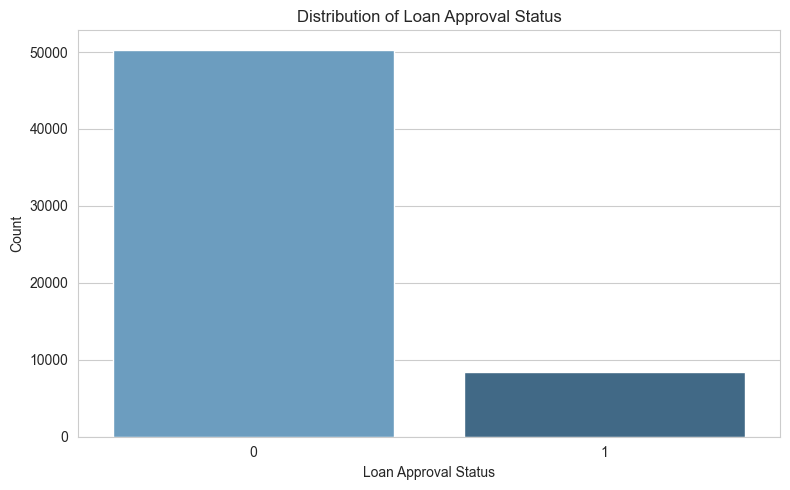

In [8]:
# Create a new figure with a readable size for the target distribution plot.
plt.figure(figsize=(8, 5))
# Build a Series of class counts sorted by class label for plotting.
target_counts = y_class.value_counts().sort_index()
# Draw a bar chart of class counts using seaborn.
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, palette="Blues_d")
# Set the chart title.
plt.title("Distribution of Loan Approval Status")
# Label the x-axis.
plt.xlabel("Loan Approval Status")
# Label the y-axis.
plt.ylabel("Count")
# Add a compact layout to avoid clipping labels.
plt.tight_layout()
# Render the bar chart.
plt.show()

## 9. Build Regression Dataset (Approved Loans Only)
Filter only approved loans, then create `X_reg` and `y_reg` where the target is Maximum Loan Amount.

In [9]:
# Create a copy of the class target series to identify approved records safely.
approval_series = df[class_target_col].copy()
# Initialize approved value with a default of 1 for common binary targets.
approved_value = 1
# Detect approved value for non-numeric targets.
if not pd.api.types.is_numeric_dtype(approval_series):
    # Convert unique class values to lowercase strings for pattern matching.
    unique_values = [str(v).strip().lower() for v in approval_series.dropna().unique().tolist()]
    # Build a list of possible approval labels.
    approval_candidates = ["approved", "approve", "yes", "y", "true", "1"]
    # Find all values that match known approval labels.
    matched_values = [v for v in unique_values if v in approval_candidates]
    # Select the first matched approval value when available.
    if len(matched_values) > 0:
        # Update approved_value using the first matched label.
        approved_value = matched_values[0]
    # Convert the original approval series to lowercase strings for filtering.
    approval_series = approval_series.astype(str).str.strip().str.lower()
# Detect approved value for numeric targets.
if pd.api.types.is_numeric_dtype(df[class_target_col]):
    # Use 1 if it exists, otherwise use the maximum value as approved class.
    approved_value = 1 if 1 in set(df[class_target_col].unique()) else df[class_target_col].max()
    # Keep the numeric approval series unchanged for filtering.
    approval_series = df[class_target_col]
# Filter the dataset to include only approved loan records.
approved_df = df[approval_series == approved_value].copy()
# Raise an error if filtering results in zero approved records.
if approved_df.shape[0] == 0:
    # Stop execution to avoid creating an empty regression dataset.
    raise ValueError("No approved loans were found. Please inspect class labels.")
# Build the regression feature matrix by dropping regression target and class target.
X_reg = approved_df.drop(columns=[reg_target_col, class_target_col], errors="ignore").copy()
# Build the regression target vector from the maximum loan amount column.
y_reg = approved_df[reg_target_col].copy()
# One-hot encode categorical columns in the regression feature matrix.
X_reg = pd.get_dummies(X_reg, drop_first=False)
# Print the shape of regression features and target.
print("Approved records for regression:", approved_df.shape[0])
# Print the shape of regression feature matrix.
print("X_reg shape:", X_reg.shape)
# Print the shape of regression target vector.
print("y_reg shape:", y_reg.shape)
# Display the first few rows of classification features.
print("\nClassification features preview (X_class):")
# Show a preview of X_class.
display(X_class.head())
# Display the first few rows of regression features.
print("Regression features preview (X_reg):")
# Show a preview of X_reg.
display(X_reg.head())

Approved records for regression: 8350
X_reg shape: (8350, 19)
y_reg shape: (8350,)

Classification features preview (X_class):


,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,max_allowed_loan,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_N,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,-2426900,False,False,True,False,False,True,False,False,False,False,True,False
1,21.0,13200,2,25000,16.77,0.19,3,-111739,False,False,True,False,False,True,False,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,-89000,False,False,False,True,False,False,False,True,False,False,True,False
3,40.0,182004,3,35000,8.00,0.19,11,35000,False,False,False,True,False,True,False,False,False,False,True,False
4,40.0,90000,3,35000,12.42,0.39,14,35000,True,False,False,False,False,False,True,False,False,False,True,False


Regression features preview (X_reg):


,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_N,payment_default_on_file_Y
379,20.0,127000,2,24250,15.31,0.19,4,True,False,False,False,True,False,False,False,False,False,True,False
380,20.0,95950,2,28250,14.54,0.27,4,False,False,False,True,False,True,False,False,False,False,True,False
381,20.0,59000,1,16800,12.42,0.29,2,False,False,False,True,False,False,False,False,True,False,True,False
382,21.0,30000,5,6500,14.27,0.22,4,False,False,False,True,False,False,True,False,False,False,True,False
383,21.0,31000,5,10000,11.49,0.32,2,False,False,False,True,False,True,False,False,False,False,True,False


## 10. Final Output Summary
At this point, the notebook has created:
- `X_class` and `y_class` for classification
- `X_reg` and `y_reg` for regression (approved loans only)

These datasets are now ready for model training in later coursework sections.